In [1]:
import pandas 
from collections import defaultdict
import numpy as np
import demes
import moments 
import dpluspy
import demesdraw
import scipy
import matplotlib, matplotlib.pylab as plt

In [2]:
# Parse likelihoods from bootstrap reps

models = [
    "null_model", # model 0
    "admix_model", # model 1
    "deep_struc_model", # model 2
    "shallow_struc_model" # model 3
]

ll_dict = {
    "model": [],
    "rep": [],
    "ll": []
}

for model in models:
    for rep in range(100):
        fname = f"fitted_models/{model}_Bherer_rep_{rep}.yaml"
        try:
            ll = demes.load(fname).metadata["opt_info"]["ll"]
            ll_dict["ll"].append(ll)
        except:
            ll_dict["ll"].append(np.nan)
        ll_dict["model"].append(model)
        ll_dict["rep"].append(rep)

df = pandas.DataFrame(ll_dict)
df.to_csv("lrt_table.csv", index=0)
print(df)

                   model  rep          ll
0             null_model    0 -571.782090
1             null_model    1 -505.892667
2             null_model    2 -494.331426
3             null_model    3 -616.812417
4             null_model    4 -714.297197
..                   ...  ...         ...
395  shallow_struc_model   95         NaN
396  shallow_struc_model   96         NaN
397  shallow_struc_model   97         NaN
398  shallow_struc_model   98         NaN
399  shallow_struc_model   99         NaN

[400 rows x 3 columns]


In [3]:
# bootstrap uncerts for model 1

param_file = "models/admix_model_params.yaml"
pdict = defaultdict(list)

for rep in range(100):
    fname = f"fitted_models/admix_model_Bherer_rep_{rep}.yaml"
    try:
        pnames, ps = dpluspy.inference._load_params(fname, param_file)
        for pname, p in zip(pnames, ps):
            pdict[pname].append(p)
    except: 
        pass

param_df = pandas.DataFrame(pdict)
param_df.to_csv("model_2_Bherer_bootstrap_mle.csv", index=0)
for col in param_df.columns:
    print(col, 1.96 * np.std(param_df[col]))

T_NH 55928.510129208305
T_H_N 57764.39761451835
T_OOA 24433.08179077424
T_UL 5.386900288737085
T_LS 3944.9038490643934
T_L_S 4.0415039496704624e-08
N_Anc 883.9407807405196
N_Vin 212.7710271475547
N_H 3918.5406323784623
N_Yor 2763.2443049155436
N_OOA 995.0745802861942
N_Stu 2044.25021000402
N_Ust 6223.763758978013
N_Los 155.01680218846104
p_H_N 0.05139616825237915
p_N_OOA 0.008459771673183573
p_L_S 0.05217407795630775
m_SY 3.5489243247201246e-17
m_LY 3.202472677758571e-05
m_LS 3.215118746031615e-05


In [4]:
ll_0 = np.array(df[df["model"] == "null_model"]["ll"])
ll_1 = np.array(df[df["model"] == "admix_model"]["ll"])
D_1_0 = 2 * (ll_1 - ll_0)
print(D_1_0)

[445.21730318 452.60821059 276.60241086          nan          nan
          nan 560.66808008          nan 393.10626718 415.50064439
          nan 320.2858299  607.63216936 344.21785242 352.98073037
 483.71975688          nan          nan 403.26053309 321.55617757
          nan 408.00734793 580.88979154          nan 379.07882378
 248.59847907          nan 358.89651772 356.77401781 326.77393183
          nan 396.84902314          nan          nan 441.8708856
          nan          nan 445.4478633  493.87673514 545.43157892
 282.68771714 486.79822483          nan 414.52881574 313.78403285
 369.59874201          nan 380.8886281           nan 575.49997615
          nan 330.12897886 331.75667303 405.63264866 297.7534142
 274.11139239 405.00943999 517.43764709 414.00077457 460.89112326
 353.64056382          nan 445.24733931          nan          nan
 545.67061523 512.08223757 437.97285588          nan          nan
          nan 482.95269621 427.61159356          nan          nan
          na

In [5]:
# models
graph0 = "../mass_fit_3/fitted_models/null_model_fit_8.yaml"
graph1 = "../mass_fit_3/fitted_models/admix_model_fit_24.yaml"
graph2 = "../mass_fit_3/fitted_models/deep_struc_model_fit_4.yaml"
graph3 = ""

data_file = "../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
u = 1.3e-8

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph0, return_dict=True)

data2 = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph2, return_dict=True)

model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model2 = dpluspy.inference.compute_bin_stats(graph2, 
    sampled_demes=data2["pop_ids"], bins=data2["bins"], u=u)

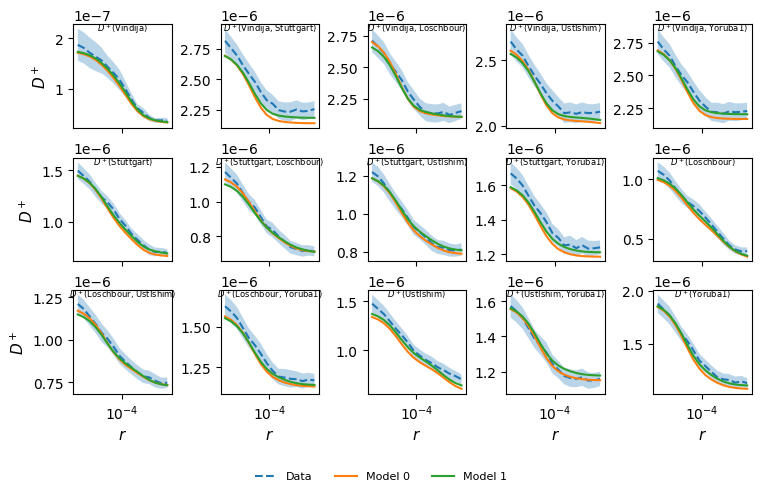

In [6]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1],
    means=data["means"],
    varcovs=data["varcovs"],
    bins=data["bins"],
    pop_ids=data["pop_ids"],
    ax_size=1.5
)

In [7]:
print(model1.pop_ids)
print(model1.names()[0])

['Vindija', 'Stuttgart', 'Loschbour', 'UstIshim', 'Yoruba1']
['D+_0_0', 'D+_0_1', 'D+_0_2', 'D+_0_3', 'D+_0_4', 'D+_1_1', 'D+_1_2', 'D+_1_3', 'D+_1_4', 'D+_2_2', 'D+_2_3', 'D+_2_4', 'D+_3_3', 'D+_3_4', 'D+_4_4']


In [8]:
def plot_on_ax(ax, data, model, stats, labels, colors, title):
    means = data["means"]
    v = data["varcovs"]
    bins = data["bins"]
    x = (bins[1:] + bins[:-1]) / 2
    pop_ids = data["pop_ids"]
    statistics = model.names()[0]

    for j, stat in enumerate(stats):
        k = statistics.index(stat)
        label = labels[j]
        err = np.array([v[l][k, k] ** 0.5 * 1.96 for l in range(len(x))])
        y = np.array([means[j][k] for j in range(len(x))])
        ax.fill_between(x, y - err, y + err, alpha=0.3, color=colors[j],
                        edgecolor='none')
        ax.plot(x, y, linestyle="dashed", color=colors[j])
        y = [model[l][k] for l in range(len(x))]
        ax.plot(x, y, color=colors[j], label=label)
    # ax setup
    # logfmt = matplotlib.ticker.LogFormatterExponent(base=10.0, labelOnlyBase=True)
    # ax.yaxis.set_major_formatter(logfmt)
    ax.set_xscale("log")
    ax.set_title(title, fontsize=7,)
    #ax.set_xlabel("$r$")
    #ax.set_xlabel("$D^+$")


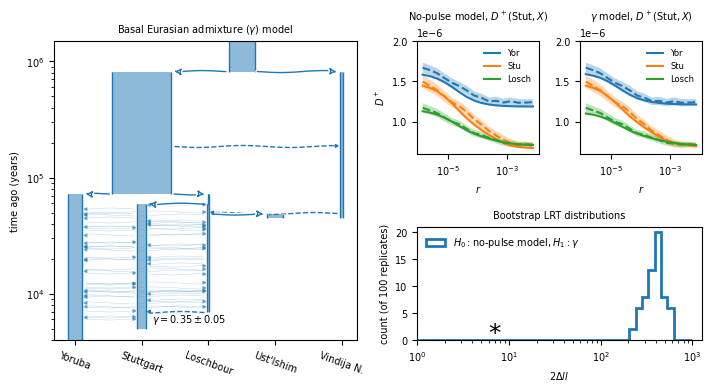

In [9]:
matplotlib.rc("font", size=7)
matplotlib.rc("xtick", labelsize=7)
matplotlib.rc("ytick", labelsize=7)
matplotlib.rc("axes", labelsize=7)
matplotlib.rc("axes", titlesize=7)
matplotlib.rc("legend", fontsize=7)

mosaic = """
ABC
ADD
"""
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 3.8), layout="constrained",
    width_ratios=[2.5, 1, 1])


graph = demes.load("edited_models/admix_model_fit_24.yaml")
positions = {
    "Yoruba1": 0,
    "Stuttgart": 40000,
    "Loschbour": 80000,
    "UstIshim": 120000,
    "Vindija": 160000,
    "Anc": 100000,
    "MH": 40000,
}
samples = ["Yoruba1", "Stuttgart", "Loschbour", "UstIshim", "Vindija"]
labels = ["Yoruba", "Stuttgart", "Loschbour", "Ust'Ishim", "Vindija N."]

axs["A"].set_title(r"Basal Eurasian admixture ($\gamma$) model")
demesdraw.tubes(
    graph,
    ax=axs["A"],
    max_time=1.5e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)
xlocs = [positions[sample] for sample in samples]
axs["A"].tick_params(axis="x", reset=True, bottom=True, top=False)
axs["A"].set_xticks(xlocs, labels, rotation=-20)
axs["A"].set_ylim(4e3, )
axs["A"].annotate(r"$\gamma=0.35\pm 0.05$", (46000, 5700))


bins = np.concatenate([[0], np.logspace(1, 3, 30)])
axs["D"].hist(D_1_0, bins=bins, fill=False, edgecolor="tab:blue", linewidth=2, 
    histtype="step", label=r"$H_0: \text{no-pulse model}, H_1: \gamma$")
axs["D"].set_xscale("log")
axs["D"].annotate("*", (scipy.stats.chi2.ppf(0.95, 2), 0), color="black",
    fontsize=18)
axs["D"].set_xlim(1,)
axs["D"].set_ylabel("count (of 100 replicates)")
axs["D"].set_xlabel(r"$2\Delta ll$")
axs["D"].legend(framealpha=0, loc="upper left")
axs["D"].set_title("Bootstrap LRT distributions")


plot_on_ax(
    axs["B"], 
    data, 
    model0, 
    ["D+_1_4", "D+_1_1","D+_1_2", ],
    ["Yor", "Stu", "Losch"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"No-pulse model, $D^+(\text{Stut}, X)$"
)
axs["B"].legend(framealpha=0, fontsize=6, loc="upper right", ncols=1)
plot_on_ax(
    axs["C"], 
    data, 
    model1, 
    ["D+_1_4", "D+_1_1","D+_1_2", ],
    ["Yor", "Stu", "Losch"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\gamma$ model, $D^+(\text{Stut}, X)$"
)
axs["C"].legend(framealpha=0, fontsize=6, loc="upper right", ncols=1)
axs["C"].set_ylim(6e-7, 2e-6)
axs["B"].set_ylim(6e-7, 2e-6)
axs["B"].sharey(axs["C"])

axs["B"].set_ylabel("$D^+$")
axs["B"].set_xlabel("$r$")
axs["C"].set_xlabel("$r$")

plt.savefig("figures/poster_figure_1.svg", transparent=True)

In [10]:
print(model1.pop_ids)
print(model2.pop_ids)

['Vindija', 'Stuttgart', 'Loschbour', 'UstIshim', 'Yoruba1']
['Vindija', 'Stuttgart', 'Loschbour', 'Yoruba1']


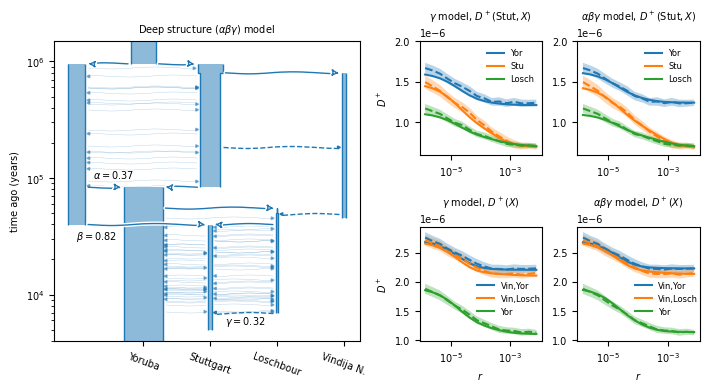

In [11]:
matplotlib.rc("font", size=7)
matplotlib.rc("xtick", labelsize=7)
matplotlib.rc("ytick", labelsize=7)
matplotlib.rc("axes", labelsize=7)
matplotlib.rc("axes", titlesize=7)
matplotlib.rc("legend", fontsize=7)

mosaic = """
ABC
ADE
"""
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 3.8), layout="constrained",
    width_ratios=[2.5, 1, 1])


graph = demes.load(graph2)
positions = {
    "Yoruba1": 0,
    "Stuttgart": 40000,
    "Loschbour": 80000,
    "Vindija": 120000,
    "Anc": 0,
    "Stem1": 40000,
    "Stem2": -40000,
}
samples = ["Yoruba1", "Stuttgart", "Loschbour", "Vindija"]
labels = ["Yoruba", "Stuttgart", "Loschbour", "Vindija N."]

axs["A"].set_title(r"Deep structure ($\alpha \beta \gamma$) model")
demesdraw.tubes(
    graph,
    ax=axs["A"],
    max_time=1.5e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)
xlocs = [positions[sample] for sample in samples]
axs["A"].tick_params(axis="x", reset=True, bottom=True, top=False)
axs["A"].set_xticks(xlocs, labels, rotation=-20)
axs["A"].set_ylim(4e3, )
axs["A"].annotate(r"$\gamma=0.32$", (49000, 5500))
axs["A"].annotate(r"$\alpha=0.37$", (-30000, 100000))
axs["A"].annotate(r"$\beta=0.82$", (-40000, 30000))


plot_on_ax(
    axs["B"], 
    data, 
    model1, 
    ["D+_1_4", "D+_1_1","D+_1_2", ],
    ["Yor", "Stu", "Losch"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\gamma$ model, $D^+(\text{Stut}, X)$"
)
axs["B"].legend(framealpha=0, fontsize=6, loc="upper right", ncols=1)
plot_on_ax(
    axs["C"], 
    data2, 
    model2, 
    ["D+_1_3", "D+_1_1","D+_1_2", ],
    ["Yor", "Stu", "Losch"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\alpha\beta\gamma$ model, $D^+(\text{Stut}, X)$"
)
axs["C"].legend(framealpha=0, fontsize=6, loc="upper right", ncols=1)
axs["C"].set_ylim(6e-7, 2e-6)
axs["B"].set_ylim(6e-7, 2e-6)
axs["B"].sharey(axs["C"])

plot_on_ax(
    axs["D"], 
    data, 
    model1, 
    ["D+_0_4", "D+_0_2","D+_4_4", ],
    ["Vin,Yor", "Vin,Losch", "Yor"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\gamma$ model, $D^+(X)$"
)
axs["D"].legend(framealpha=0, fontsize=6, loc="center right", ncols=1,
                bbox_to_anchor=(1.05, 0.37))
plot_on_ax(
    axs["E"], 
    data2, 
    model2, 
    ["D+_0_3", "D+_0_2","D+_3_3", ],
    ["Vin,Yor", "Vin,Losch", "Yor"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\alpha\beta\gamma$ model, $D^+(X)$"
)
axs["E"].legend(framealpha=0, fontsize=6, loc="center right", ncols=1,
                bbox_to_anchor=(1.05, 0.37))
axs["D"].sharey(axs["E"])

axs["B"].set_ylabel("$D^+$")
axs["D"].set_ylabel("$D^+$")
axs["D"].set_xlabel("$r$")
axs["E"].set_xlabel("$r$")

plt.savefig("figures/poster_figure_2.png", dpi=244)